# Full Pipeline Demo: Remote Work & Algorithmic Management

This notebook demonstrates the complete **siamang** workflow:
1. **Survey Design** — variables, questions, pages with conditional routing
2. **HTML Preview** — rendering the survey as a standalone HTML file
3. **Database Storage** — SQLite backend for collecting responses
4. **Simulation** — generating synthetic respondent data
5. **Statistical Analysis** — frequencies, cross-tabs, correlations, visualizations

> **Research topic**: How digital monitoring and algorithmic management affect job satisfaction and perceived autonomy among IT professionals working remotely.

## 1. Setup & Imports

In [1]:
from siamang import *
from siamang.frontend import SurveyJSRuntime, UIConfig, compile_questionnaire
from siamang.frontend.runtime.base import RuntimeRenderContext
from siamang.frontend.theme.css import compile_css
from siamang.deploy.backends.local import LocalBackend

import pandas as pd
import numpy as np
import sqlite3
import json
from contextlib import closing
from pathlib import Path
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="muted")
print("siamang loaded successfully")

siamang loaded successfully


## 2. Variable Definitions

Each variable is defined with its measurement scale, labels, and validation constraints.
This metadata drives the entire pipeline — from rendering to analysis.

In [2]:
consent = Variable("consent", scale="nominal", label="Informed Consent",
                   labels={1: "Yes, I agree to participate", 0: "No, I do not wish to participate"})

age = Variable("age", scale="ratio", label="Age", dtype="int", valid_range=(18, 75))

gender = Variable("gender", scale="nominal", label="Gender Identity",
                  labels={1: "Male", 2: "Female", 3: "Non-binary", 4: "Prefer not to say"})

it_role = Variable("it_role", scale="nominal", label="IT Role",
                   labels={1: "Software Engineer", 2: "Data Scientist / ML Engineer",
                           3: "DevOps / SRE", 4: "Product Manager", 5: "Other"})

experience = Variable("experience", scale="ratio", label="Years of Experience",
                      dtype="int", valid_range=(0, 50))

remote_freq = Variable("remote_freq", scale="ordinal", label="Remote Work Frequency",
                       labels={1: "Never (fully on-site)", 2: "Occasionally (1-2 days/month)",
                               3: "Hybrid (2-3 days/week)", 4: "Mostly remote (4+ days/week)",
                               5: "Fully remote"})

surv_keystroke = Variable("surv_keystroke", scale="ordinal",
                          label="Keystroke logging / activity tracking",
                          labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                                  4: "Agree", 5: "Strongly agree"})
surv_camera = Variable("surv_camera", scale="ordinal",
                       label="Webcam monitoring / periodic screenshots",
                       labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                               4: "Agree", 5: "Strongly agree"})
surv_git = Variable("surv_git", scale="ordinal",
                    label="Git commit frequency metrics",
                    labels={1: "Strongly disagree", 2: "Disagree", 3: "Neutral",
                            4: "Agree", 5: "Strongly agree"})

satisfaction = Variable("satisfaction", scale="ordinal", label="Overall Job Satisfaction",
                        labels={1: "Very dissatisfied", 2: "Dissatisfied", 3: "Neutral",
                                4: "Satisfied", 5: "Very satisfied"})
autonomy = Variable("autonomy", scale="ordinal", label="Workplace Autonomy",
                    labels={1: "Very low", 2: "Low", 3: "Moderate", 4: "High", 5: "Very high"})
story = Variable("story", scale="nominal", label="Experience with algorithmic management")

print(f"Defined 12 variables")

Defined 12 variables


## 3. Questionnaire Assembly

Questions are organized into pages with conditional routing:
- **Page 1** (Consent) — always shown
- **Pages 2-6** — shown only if `consent == 1`
- **Page 4** (Surveillance) — additionally requires `remote_freq >= 2`

In [3]:
q_consent = SingleChoice(
    text="Do you consent to participate in this research study on remote work and digital monitoring?",
    var=consent, required=True, display="buttons")

q_age = NumericInput("What is your age?", var=age, required=True)
q_gender = SingleChoice("How do you identify?", var=gender, required=True, display="radio")

q_role = SingleChoice("What is your primary IT role?", var=it_role, required=True, display="dropdown")
q_exp = NumericInput("How many years of professional IT experience do you have?",
                     var=experience, required=True)
q_remote = SingleChoice("How often do you work remotely?", var=remote_freq, required=True, display="radio")

q_surv = Matrix(
    text="To what extent do you agree that the following monitoring tools are used at your workplace?",
    var=[surv_keystroke, surv_camera, surv_git],
    subquestions=["Keystroke / activity logging", "Webcam / screenshot monitoring",
                  "Git commit frequency tracking"],
    column_labels=["Strongly disagree", "Disagree", "Neutral", "Agree", "Strongly agree"])

q_sat = LikertScale("How satisfied are you with your current job overall?",
                    var=satisfaction, points=5,
                    left_label="Very dissatisfied", right_label="Very satisfied")
q_aut = LikertScale("How much autonomy do you have in deciding how to do your work?",
                    var=autonomy, points=5,
                    left_label="Very low", right_label="Very high")

q_story = OpenText(
    "Please share any experience you have had with algorithmic management or automated monitoring at work.",
    var=story, multiline=True, max_chars=2000,
    placeholder="Your experience here...")

# Pages with conditional routing
page1 = Page(name="consent", title="Informed Consent", items=[q_consent])
page2 = Page(name="demographics", title="Demographics",
             items=[q_age, q_gender], show_if=consent.eq(1))
page3 = Page(name="professional", title="Professional Background",
             items=[q_role, q_exp, q_remote], show_if=consent.eq(1))
page4 = Page(name="surveillance", title="Workplace Monitoring",
             items=[q_surv], show_if=AND(consent.eq(1), remote_freq.ge(2)))
page5 = Page(name="outcomes", title="Work Outcomes",
             items=[q_sat, q_aut], show_if=consent.eq(1))
page6 = Page(name="qualitative", title="Your Experience",
             items=[q_story], show_if=consent.eq(1))

# Assemble
variables = VariableMap()
variables.add_many([consent, age, gender, it_role, experience, remote_freq,
                    surv_keystroke, surv_camera, surv_git, satisfaction, autonomy, story])

survey = Questionnaire(
    title="Remote Work & Algorithmic Management in IT",
    pages=[page1, page2, page3, page4, page5, page6],
    variables=variables)

print(f"Questionnaire: '{survey.title}'")
print(f"  Pages: {len(survey.pages)}")
print(f"  Questions: {len(survey.all_questions())}")
print(f"  Variables: {len(variables)}")
print(f"  Routing rules:")
for p in survey.pages:
    cond = str(p.show_if) if p.show_if else "always"
    print(f"    {p.name:15s} -> {cond}")

Questionnaire: 'Remote Work & Algorithmic Management in IT'
  Pages: 6
  Questions: 10
  Variables: 12
  Routing rules:
    consent         -> always
    demographics    -> {consent} = 1
    professional    -> {consent} = 1
    surveillance    -> ({consent} = 1) and ({remote_freq} >= 2)
    outcomes        -> {consent} = 1
    qualitative     -> {consent} = 1


## 4. HTML Survey Preview

Siamang compiles the questionnaire into a standalone HTML file using the SurveyJS engine.
This is what respondents see in their browser.

In [4]:
schema = compile_questionnaire(survey)

runtime = SurveyJSRuntime()
ui = UIConfig()
context = RuntimeRenderContext(schema=schema, ui=ui, css_href="style.css", env_src="env.js")

html_content = runtime.render_html(context)
css_content = compile_css(ui)

env_js = """
window.SIAMANG_ENV = {"transport": "demo", "survey_id": "demo_preview"};
window.SIAMANG_TRANSPORTS = window.SIAMANG_TRANSPORTS || {};
window.SIAMANG_TRANSPORTS.demo = {
  async submit(responses) {
    alert("Survey completed! Responses: " + JSON.stringify(responses, null, 2));
    return { ok: true };
  },
  async checkQuota() { return { ok: true }; }
};
"""

html_standalone = html_content.replace(
    '<link rel="stylesheet" href="style.css">',
    f'<style>\n{css_content}\n</style>'
).replace(
    '<script src="env.js"></script>',
    f'<script>\n{env_js}\n</script>'
)

Path("survey_preview.html").write_text(html_standalone, encoding="utf-8")
print(f"survey_preview.html saved ({len(html_standalone) / 1024:.1f} KB)")
print(f"Open in browser to interact with the survey")
print()
print("SurveyJS schema preview (first page):")
print(json.dumps(schema.to_surveyjs()["pages"][0], indent=2, ensure_ascii=False)[:500])

survey_preview.html saved (17.6 KB)
Open in browser to interact with the survey

SurveyJS schema preview (first page):
{
  "name": "consent",
  "title": "Informed Consent",
  "elements": [
    {
      "id": "consent",
      "name": "consent",
      "title": "Do you consent to participate in this research study on remote work and digital monitoring?",
      "isRequired": true,
      "type": "radiogroup",
      "choices": [
        {
          "value": 1,
          "text": "Yes, I agree to participate"
        },
        {
          "value": 0,
          "text": "No, I do not wish to participate"
        }
      ]


## 5. Database Storage (SQLite)

Siamang uses SQLite for local deployments. The database stores:
- **survey_meta** — survey configuration and schema
- **responses** — individual respondent answers as JSON
- **quota_counters** — sample quota tracking

In [5]:
db_path = Path("survey_responses.db")
if db_path.exists():
    db_path.unlink()

backend = LocalBackend(path=str(db_path))
backend_config = backend.provision(schema)
survey_id = backend_config.survey_id

print(f"Database created: {db_path}")
print(f"  Survey ID: {survey_id}")
print()
print("Database schema:")
with closing(sqlite3.connect(db_path)) as conn:
    tables = conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()
    for (table,) in tables:
        cols = conn.execute(f"PRAGMA table_info({table})").fetchall()
        col_names = [c[1] for c in cols]
        print(f"  {table}: {col_names}")

Database created: survey_responses.db
  Survey ID: 2a18bedd4ceb

Database schema:
  survey_meta: ['survey_id', 'title', 'schema_json', 'max_responses', 'created_at']
  responses: ['id', 'survey_id', 'payload_json', 'submitted_at']
  sqlite_sequence: ['name', 'seq']
  quota_counters: ['survey_id', 'variable', 'value', 'target', 'current']


## 6. Data Simulation

The simulator respects page-level `show_if` conditions:
- Respondents with `consent=0` get NaN for all subsequent variables
- Respondents with `remote_freq=1` (never remote) skip the surveillance page

In [6]:
data = survey.simulate(n=250, seed=42)
df = data.frame

print(f"DataFrame shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print()
print("First 10 rows:")
df.head(10)

DataFrame shape: (250, 12)
Columns: ['consent', 'age', 'gender', 'it_role', 'experience', 'remote_freq', 'surv_keystroke', 'surv_camera', 'surv_git', 'satisfaction', 'autonomy', 'story']

First 10 rows:


,consent,age,gender,it_role,experience,remote_freq,surv_keystroke,surv_camera,surv_git,satisfaction,autonomy,story
0,1,19.0,3.0,2.0,14.0,2.0,1.0,5.0,1.0,5.0,4.0,sample text
1,1,19.0,1.0,2.0,14.0,5.0,5.0,1.0,5.0,2.0,5.0,sample text
2,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1,46.0,3.0,1.0,48.0,2.0,4.0,3.0,3.0,2.0,2.0,sample text
4,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1,23.0,4.0,1.0,22.0,3.0,5.0,3.0,1.0,4.0,5.0,sample text
6,1,42.0,1.0,5.0,18.0,5.0,3.0,5.0,2.0,1.0,1.0,sample text
7,1,67.0,3.0,1.0,14.0,1.0,NaN,NaN,NaN,4.0,3.0,sample text
8,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
for _, row in df.iterrows():
    payload = {}
    for col in df.columns:
        val = row[col]
        if val is not None and not (isinstance(val, float) and np.isnan(val)):
            if isinstance(val, (np.integer,)):
                val = int(val)
            elif isinstance(val, (np.floating,)):
                val = float(val)
            payload[col] = val
    if payload:
        backend.store_response(survey_id, payload)

with closing(sqlite3.connect(db_path)) as conn:
    count = conn.execute("SELECT COUNT(*) FROM responses").fetchone()[0]
    print(f"{count} responses stored in database")
    print()
    row = conn.execute("SELECT id, payload_json, submitted_at FROM responses LIMIT 1").fetchone()
    print(f"Sample record (id={row[0]}, submitted={row[2]}):")
    payload = json.loads(row[1])
    for k, v in payload.items():
        print(f"  {k}: {v}")

250 responses stored in database

Sample record (id=1, submitted=2026-05-28 19:28:57):
  consent: 1
  age: 19.0
  gender: 3.0
  it_role: 2.0
  experience: 14.0
  remote_freq: 2.0
  surv_keystroke: 1.0
  surv_camera: 5.0
  surv_git: 1.0
  satisfaction: 5.0
  autonomy: 4.0
  story: sample text


## 7. Data Exploration

### Variable Summary

In [8]:
desc = data.describe_variables()
desc

,name,label,scale,n,n_missing,n_unique
0,consent,Informed Consent,nominal,250,0,2
1,age,Age,ratio,250,122,51
2,gender,Gender Identity,nominal,250,122,4
3,it_role,IT Role,nominal,250,122,5
4,experience,Years of Experience,ratio,250,122,44
5,remote_freq,Remote Work Frequency,ordinal,250,122,5
6,surv_keystroke,Keystroke logging / activity tracking,ordinal,250,142,5
7,surv_camera,Webcam monitoring / periodic screenshots,ordinal,250,142,5
8,surv_git,Git commit frequency metrics,ordinal,250,142,5
9,satisfaction,Overall Job Satisfaction,ordinal,250,122,5


### Missing Data Pattern

In [9]:
print("Missing data pattern (caused by conditional page routing):")
print(f"  consent=0 (refused): {(df['consent'] == 0).sum()} respondents -> all subsequent = NaN")
consent_yes = df['consent'] == 1
remote_onsite = consent_yes & (df['remote_freq'] == 1)
print(f"  consent=1, remote=Never: {remote_onsite.sum()} respondents -> surveillance = NaN")
eligible = consent_yes & (df['remote_freq'] >= 2)
print(f"  consent=1, remote>=2 (eligible for surveillance): {eligible.sum()} respondents")
print(f"  Surveillance variables non-null: {df['surv_keystroke'].notna().sum()} / {len(df)}")

Missing data pattern (caused by conditional page routing):
  consent=0 (refused): 122 respondents -> all subsequent = NaN
  consent=1, remote=Never: 20 respondents -> surveillance = NaN
  consent=1, remote>=2 (eligible for surveillance): 108 respondents
  Surveillance variables non-null: 108 / 250


### Data Validation

In [10]:
issues = data.validate()
if issues:
    print(f"{len(issues)} validation issues found:")
    for issue in issues[:5]:
        print(f"  - {issue}")
else:
    print("All data matches the codebook perfectly!")

All data matches the codebook perfectly!


## 8. Statistical Analysis

### Frequency Distributions

In [11]:
role_data = df.loc[df['consent'] == 1, 'it_role'].dropna()
freq = role_data.value_counts().sort_index()
freq.index = [it_role.labels.get(int(k), k) for k in freq.index]
freq_pct = (freq / freq.sum() * 100).round(1)

print("IT Role Distribution:")
print("=" * 50)
for label, count in freq.items():
    pct = freq_pct[label]
    bar = "#" * int(pct / 2)
    print(f"  {label:30s} {count:3d} ({pct:5.1f}%) {bar}")
print(f"  {'TOTAL':30s} {freq.sum():3d}")

IT Role Distribution:
  Software Engineer               23 ( 18.0%) #########
  Data Scientist / ML Engineer    33 ( 25.8%) ############
  DevOps / SRE                    25 ( 19.5%) #########
  Product Manager                 20 ( 15.6%) #######
  Other                           27 ( 21.1%) ##########
  TOTAL                          128


In [12]:
remote_data = df.loc[df['consent'] == 1, 'remote_freq'].dropna()
freq_r = remote_data.value_counts().sort_index()
freq_r.index = [remote_freq.labels.get(int(k), k) for k in freq_r.index]

print("Remote Work Frequency:")
print("=" * 55)
for label, count in freq_r.items():
    pct = count / freq_r.sum() * 100
    bar = "#" * int(pct / 2)
    print(f"  {label:35s} {count:3d} ({pct:5.1f}%) {bar}")

Remote Work Frequency:
  Never (fully on-site)                20 ( 15.6%) #######
  Occasionally (1-2 days/month)        24 ( 18.8%) #########
  Hybrid (2-3 days/week)               31 ( 24.2%) ############
  Mostly remote (4+ days/week)         24 ( 18.8%) #########
  Fully remote                         29 ( 22.7%) ###########


### Cross-tabulation: IT Role x Remote Frequency

In [13]:
table, stats_ct = data.analysis.crosstab("it_role", "remote_freq", chi2=True, cramers_v=True, labels=True)
print("Cross-tabulation: IT Role x Remote Work Frequency")
print(table)
print()
print("Chi-square test:")
print(f"  chi2 = {stats_ct['chi2']:.2f}")
print(f"  p-value = {stats_ct['p_value']:.4f}")
print(f"  Cramer's V = {stats_ct['cramers_v']:.3f}")
if stats_ct['p_value'] < 0.05:
    print("  -> Statistically significant association (p < 0.05)")
else:
    print("  -> No significant association (p >= 0.05)")

Cross-tabulation: IT Role x Remote Work Frequency
                              Never (fully on-site)  \
Software Engineer                                 3   
Data Scientist / ML Engineer                      6   
DevOps / SRE                                      4   
Product Manager                                   4   
Other                                             3   
NaN                                               0   

                              Occasionally (1-2 days/month)  \
Software Engineer                                         5   
Data Scientist / ML Engineer                              5   
DevOps / SRE                                              4   
Product Manager                                           4   
Other                                                     6   
NaN                                                       0   

                              Hybrid (2-3 days/week)  \
Software Engineer                                  6   
Data Scien

### Group Comparisons: Autonomy by Remote Frequency

In [14]:
valid = df.loc[df['consent'] == 1].dropna(subset=['remote_freq', 'autonomy'])
grouped = valid.groupby('remote_freq')['autonomy'].agg(['mean', 'std', 'count'])
grouped.index = [remote_freq.labels.get(int(k), k) for k in grouped.index]

print("Mean Autonomy by Remote Work Frequency:")
print("=" * 65)
print(f"  {'Group':35s} {'Mean':>6s} {'SD':>6s} {'N':>4s}")
print("-" * 65)
for label, row in grouped.iterrows():
    print(f"  {label:35s} {row['mean']:6.2f} {row['std']:6.2f} {int(row['count']):4d}")

groups = [g['autonomy'].values for _, g in valid.groupby('remote_freq')]
h_stat, p_val = stats.kruskal(*groups)
print()
print(f"Kruskal-Wallis H = {h_stat:.3f}, p = {p_val:.4f}")
if p_val < 0.05:
    print("-> Significant differences in autonomy across remote work groups")
else:
    print("-> No significant differences (fail to reject H0)")

Mean Autonomy by Remote Work Frequency:
  Group                                 Mean     SD    N
-----------------------------------------------------------------
  Never (fully on-site)                 3.10   1.55   20
  Occasionally (1-2 days/month)         3.21   1.35   24
  Hybrid (2-3 days/week)                2.94   1.48   31
  Mostly remote (4+ days/week)          2.75   1.15   24
  Fully remote                          3.10   1.63   29

Kruskal-Wallis H = 1.453, p = 0.8350
-> No significant differences (fail to reject H0)


### Surveillance Monitoring Prevalence

In [15]:
surv_vars = ['surv_keystroke', 'surv_camera', 'surv_git']
surv_labels = ['Keystroke logging', 'Webcam monitoring', 'Git metrics']

eligible_df = df.loc[eligible].copy()
print(f"Surveillance analysis (N = {len(eligible_df)} eligible respondents)")
print("=" * 60)
print(f"  {'Tool':25s} {'Mean':>5s} {'SD':>5s} {'% Agree':>8s}")
print("-" * 60)
for var_name, label in zip(surv_vars, surv_labels):
    col = eligible_df[var_name].dropna()
    agree_pct = (col >= 4).sum() / len(col) * 100
    print(f"  {label:25s} {col.mean():5.2f} {col.std():5.2f} {agree_pct:7.1f}%")

Surveillance analysis (N = 108 eligible respondents)
  Tool                       Mean    SD  % Agree
------------------------------------------------------------
  Keystroke logging          3.08  1.47    46.3%
  Webcam monitoring          3.18  1.48    47.2%
  Git metrics                2.81  1.43    35.2%


### Correlations: Surveillance x Outcomes

In [16]:
corr_vars = ['surv_keystroke', 'surv_camera', 'surv_git', 'satisfaction', 'autonomy']
corr_df = eligible_df[corr_vars].dropna()

print(f"Spearman correlations (N = {len(corr_df)}):")
print("=" * 70)
pairs = [
    ('surv_keystroke', 'satisfaction'),
    ('surv_keystroke', 'autonomy'),
    ('surv_camera', 'satisfaction'),
    ('surv_camera', 'autonomy'),
    ('surv_git', 'satisfaction'),
    ('surv_git', 'autonomy'),
]
for x, y in pairs:
    rho, p = stats.spearmanr(corr_df[x], corr_df[y])
    sig = "***" if p < 0.001 else "**" if p < 0.01 else "*" if p < 0.05 else "ns"
    print(f"  {x:15s} x {y:15s}: rho = {rho:+.3f}, p = {p:.4f} {sig}")

Spearman correlations (N = 108):
  surv_keystroke  x satisfaction   : rho = -0.132, p = 0.1732 ns
  surv_keystroke  x autonomy       : rho = +0.043, p = 0.6599 ns
  surv_camera     x satisfaction   : rho = +0.081, p = 0.4035 ns
  surv_camera     x autonomy       : rho = -0.081, p = 0.4065 ns
  surv_git        x satisfaction   : rho = -0.157, p = 0.1056 ns
  surv_git        x autonomy       : rho = +0.115, p = 0.2355 ns


### Visualizations

/tmp/ipykernel_13929/3168252786.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_plot, x='Remote Work', y='satisfaction', ax=axes[0], palette='Blues')
/tmp/ipykernel_13929/3168252786.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=valid_plot, x='Remote Work', y='autonomy', ax=axes[1], palette='Greens')


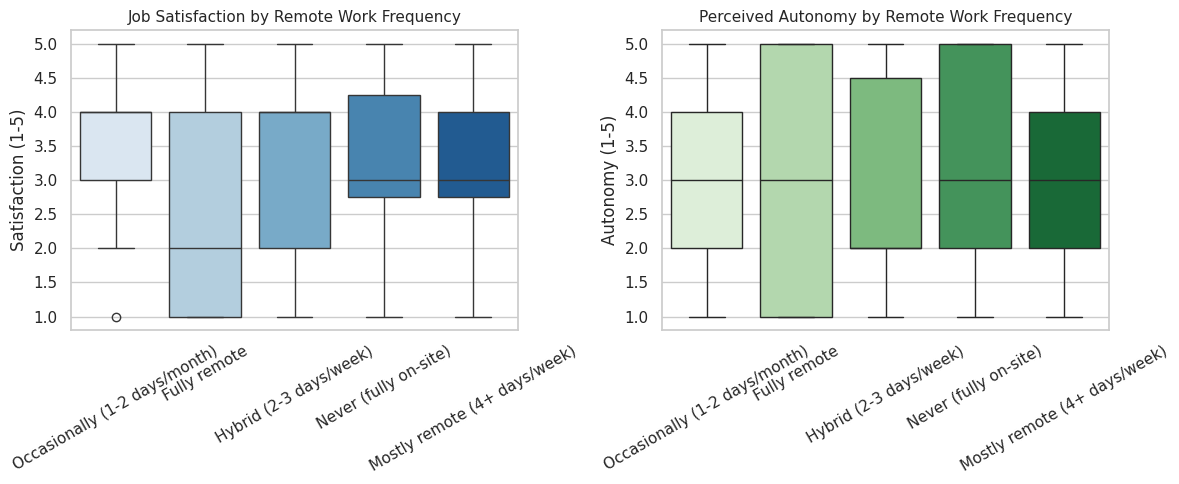

Figure saved: fig_outcomes_by_remote.png


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

valid_plot = df.loc[df['consent'] == 1].dropna(subset=['remote_freq', 'satisfaction', 'autonomy'])
valid_plot = valid_plot.copy()
valid_plot['Remote Work'] = valid_plot['remote_freq'].map(remote_freq.labels)

sns.boxplot(data=valid_plot, x='Remote Work', y='satisfaction', ax=axes[0], palette='Blues')
axes[0].set_title('Job Satisfaction by Remote Work Frequency', fontsize=11)
axes[0].set_xlabel('')
axes[0].set_ylabel('Satisfaction (1-5)')
axes[0].tick_params(axis='x', rotation=30)

sns.boxplot(data=valid_plot, x='Remote Work', y='autonomy', ax=axes[1], palette='Greens')
axes[1].set_title('Perceived Autonomy by Remote Work Frequency', fontsize=11)
axes[1].set_xlabel('')
axes[1].set_ylabel('Autonomy (1-5)')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig('fig_outcomes_by_remote.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_outcomes_by_remote.png")

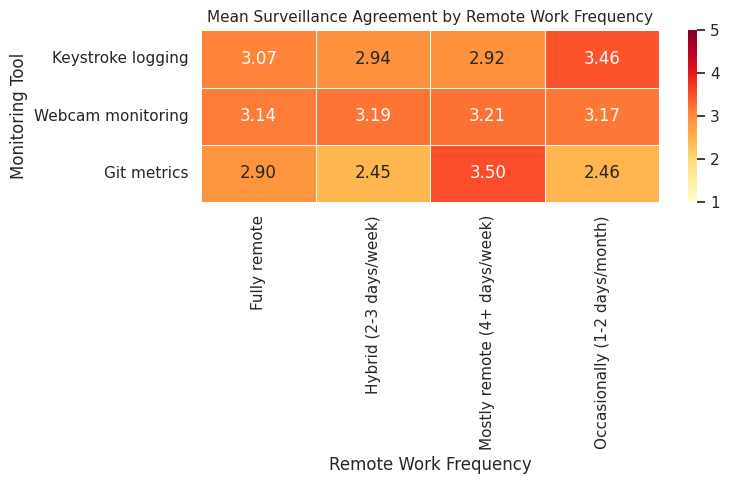

Figure saved: fig_surveillance_heatmap.png


In [18]:
fig, ax = plt.subplots(figsize=(8, 5))

surv_means = eligible_df.groupby(
    eligible_df['remote_freq'].map(remote_freq.labels)
)[surv_vars].mean()
surv_means.columns = surv_labels

sns.heatmap(surv_means.T, annot=True, fmt='.2f', cmap='YlOrRd',
            vmin=1, vmax=5, ax=ax, linewidths=0.5)
ax.set_title('Mean Surveillance Agreement by Remote Work Frequency', fontsize=11)
ax.set_xlabel('Remote Work Frequency')
ax.set_ylabel('Monitoring Tool')

plt.tight_layout()
plt.savefig('fig_surveillance_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: fig_surveillance_heatmap.png")

### Export: Banner Tables

In [19]:
banner = data.tables.banner(rows=["satisfaction"], columns=["remote_freq"])
banner.export_xlsx("banner_satisfaction_by_remote.xlsx")
print("Banner table exported: banner_satisfaction_by_remote.xlsx")
print()
print("Banner preview:")
print(banner.frame)

Banner table exported: banner_satisfaction_by_remote.xlsx

Banner preview:
    row_variable  row_value          row_label column_variable  column_value  \
0   satisfaction        1.0  Very dissatisfied     remote_freq           1.0   
1   satisfaction        1.0  Very dissatisfied     remote_freq           2.0   
2   satisfaction        1.0  Very dissatisfied     remote_freq           3.0   
3   satisfaction        1.0  Very dissatisfied     remote_freq           4.0   
4   satisfaction        1.0  Very dissatisfied     remote_freq           5.0   
5   satisfaction        2.0       Dissatisfied     remote_freq           1.0   
6   satisfaction        2.0       Dissatisfied     remote_freq           2.0   
7   satisfaction        2.0       Dissatisfied     remote_freq           3.0   
8   satisfaction        2.0       Dissatisfied     remote_freq           4.0   
9   satisfaction        2.0       Dissatisfied     remote_freq           5.0   
10  satisfaction        3.0            Neutra

## 9. Database Queries

Demonstrating how to query the SQLite database directly — useful for custom analysis
or integration with other tools (R, SPSS, Tableau).

In [20]:
with closing(sqlite3.connect("survey_responses.db")) as conn:
    meta = pd.read_sql("SELECT * FROM survey_meta", conn)
    print("survey_meta table:")
    print(f"  survey_id: {meta['survey_id'].iloc[0]}")
    print(f"  title: {meta['title'].iloc[0]}")
    print(f"  max_responses: {meta['max_responses'].iloc[0]}")
    print()

    stats_q = pd.read_sql("""
        SELECT COUNT(*) as n_responses,
               MIN(submitted_at) as first_response,
               MAX(submitted_at) as last_response
        FROM responses
    """, conn)
    print("responses table:")
    print(f"  Total: {stats_q['n_responses'].iloc[0]}")
    print(f"  First: {stats_q['first_response'].iloc[0]}")
    print(f"  Last: {stats_q['last_response'].iloc[0]}")
    print()

    responses = backend.get_responses(survey_id)
    print(f"Reconstructed DataFrame from DB: {responses.shape}")
    print(responses[['_response_id', 'consent', 'age', 'it_role', 'satisfaction']].head(5))

survey_meta table:
  survey_id: 2a18bedd4ceb
  title: Remote Work & Algorithmic Management in IT
  max_responses: None

responses table:
  Total: 250
  First: 2026-05-28 19:28:57
  Last: 2026-05-28 19:28:57

Reconstructed DataFrame from DB: (250, 14)
   _response_id  consent   age  it_role  satisfaction
0             1        1  19.0      2.0           5.0
1             2        1  19.0      2.0           2.0
2             3        0   NaN      NaN           NaN
3             4        1  46.0      1.0           2.0
4             5        0   NaN      NaN           NaN


## 10. Summary

This pipeline demonstrated the full **siamang** workflow:

| Step | Output | Description |
|:-----|:-------|:------------|
| Survey Design | `Questionnaire` object | 12 variables, 6 pages, conditional routing |
| HTML Preview | `survey_preview.html` | Standalone interactive survey (SurveyJS) |
| Database | `survey_responses.db` | SQLite with schema, responses, quotas |
| Simulation | `DataFrame (250x12)` | Synthetic data respecting page visibility |
| Analysis | Statistics + plots | Chi2, Kruskal-Wallis, Spearman, visualizations |
| Export | `.xlsx` banner tables | Publication-ready cross-tabulations |

**Key findings from simulated data:**
- Conditional routing works correctly (surveillance NaN for on-site workers)
- Database stores responses as JSON with timestamps
- The HTML survey is fully functional and can be deployed locally or on any static host
